In [1]:
# Importe aqui os pacotes que achar necessários para a execução das questões
import pandas as pd
import altair as alt
import matplotlib.pyplot as plt


# Questão 1

### Classifique as variáveis abaixo segundo seus tipos

- (a) Quantidade de homicídios no Brasil em 2023.
> quantitativa discreta
- (b) Time de futebol.
> qualitativa nominal
- (c) Taxa de desemprego.
> quantitativa contínua
- (d) Nível de satisfação com o governo do Presidente Lula
> quantitativa contínua
- (e) Denominação religiosa
> qualitativa nominal
- (f) Renda per capita
>quantitativa contínua

# Questão 2

### Qual área de estudo?

Cerca de 1,5 milhão de estudantes se matricularam em faculdades e universidades em 2008.

No arquivo HABILITA.xls estão dados sobre o percentual de estudantes de primeiro ano que pretendiam se habilitar em diversas áreas disciplinares.

- (a) Quem eram, originalmente, as observações (unidades de análise) que geraram esses dados percentuais?
> As observações originais eram os próprios estudantes calouros (do primeiro ano) individualmente. Cada estudante era uma unidade de análise, e a variável coletada para cada um era a área disciplinar que ele(a) pretendia cursar (uma variável categórica). Os percentuais apresentados no arquivo HABILITA.xls são um resumo/agregação dessas respostas individuais, ou seja, foram calculados a partir dos dados de cada estudante, e não são, eles mesmos, as observações originais.

- (b) Verifique a consistência desses dados.
>Verifiquei a consistência dos tatos para totalizarem 100%.

- (c) Faça uma análise desses dados a partir de gráficos e escreva uma breve interpretação dos resultados.
> A área com maior percentual de calouros pretendendo se habilitar foi Administração (16.8%), seguida de perto por Profissional (13.8%), Artes&Humanidades (13.5%) e Outra (13.2%) — essas quatro categorias formam um grupo de áreas com popularidade parecida entre si. No outro extremo, Técnico teve o menor percentual (apenas 1.0%), e Ciências Físicas também ficou bem baixo (3.2%), indicando pouco interesse inicial dos calouros nessas áreas. As demais áreas (Ciências Sociais, Engenharia, Ciências Biológicas e Educação) ficaram numa faixa intermediária, entre 8% e 12%. No geral, a distribuição não é uniforme entre as dez áreas — há uma concentração maior em torno de Administração e áreas afins, enquanto Técnico se destaca como um caso isolado de baixíssima procura.

In [6]:
habilita = pd.read_excel("/Users/leonardorosa/Documents/poly a1/MetodosEstatisticos_26.2/aulas_praticas/15-revisao/HABILITA.xls")

habilita

,Disciplina,Percentual
0,Artes&Humanidades,13.5
1,CiênciasBiológicas,9.3
2,Administração,16.8
3,Educação,8.2
4,Engenharia,9.4
5,CiênciasFísicas,3.2
6,Profissional,13.8
7,CiênciasSociais,11.5
8,Técnico,1.0
9,Outra,13.2


In [8]:
habilita.Percentual.sum()

np.float64(99.9)

In [15]:
habilita.loc[9,'Percentual'] = (habilita.loc[9,'Percentual']) + 100-habilita.Percentual.sum()

habilita

,Disciplina,Percentual
0,Artes&Humanidades,13.5
1,CiênciasBiológicas,9.3
2,Administração,16.8
3,Educação,8.2
4,Engenharia,9.4
5,CiênciasFísicas,3.2
6,Profissional,13.8
7,CiênciasSociais,11.5
8,Técnico,1.0
9,Outra,13.3


In [16]:
habilita.Percentual.sum()

np.float64(100.0)

### Gráfico de Setores

### com altair:

In [17]:
alt.Chart(habilita).mark_arc().encode(
    theta = "Percentual",
    color = alt.Color('Disciplina'),
    tooltip = ['Disciplina:N', 'Percentual:Q']
)

alt.Chart(...)

#### Com o plot padrão do pandas

<Axes: >

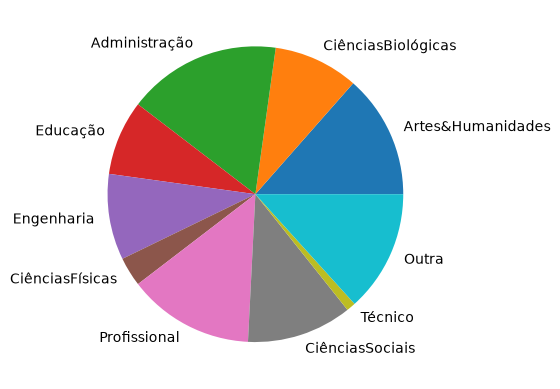

In [18]:
habilita.set_index('Disciplina').Percentual.plot.pie()

### Gráfico de Barras

### com pandas

<Axes: xlabel='Disciplina'>

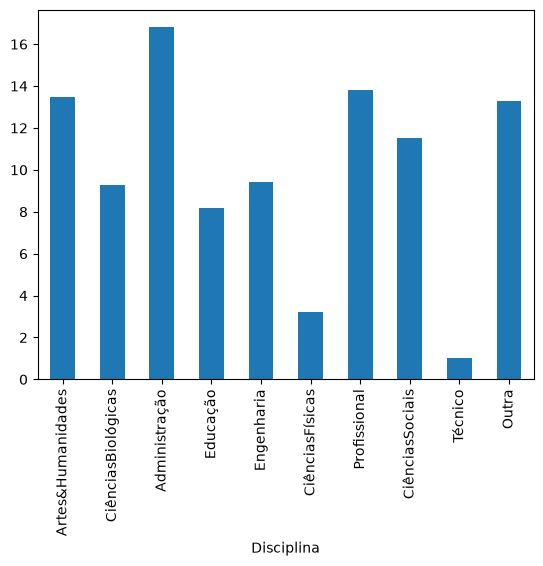

In [19]:
habilita.set_index('Disciplina').Percentual.plot.bar()

### com altair

In [22]:
alt.Chart(habilita).mark_bar().encode(
    x=alt.X("Disciplina:N", axis=alt.Axis(labelAngle=-45), sort=None),
    y="Percentual:Q"
)

alt.Chart(...)

In [23]:
# Creating a vertical bar chart
vert_bar = alt.Chart(
    habilita,
    title = alt.TitleParams('Habilitação', fontSize = 20, anchor='start')  # Adding a title with specific font size
).mark_bar().encode(
    y = alt.Y(
        'Percentual:Q',
        axis = alt.Axis(
            title = "% de estudantes que pretendem uma habilitação",  # Setting a custom title for the y-axis
            titleAlign = 'left',  # Aligning the title to the left
            titleAngle = 0,  # Setting the title angle to 0 degrees
            titleAnchor = 'end',  # Anchoring the title to the end
            titleY = -10,  # Adjusting the title position
            grid = False,  # Turning off grid lines
            labelColor = "#888888",  # Setting the label color to gray
            titleColor = '#888888'  # Setting the title color to gray
        )
    ),
    x = alt.X(
        'Disciplina:N',
        axis=alt.Axis(labelAngle=-45, ticks = False),
        sort='-y'
    )
).properties(
    width = 500  # Setting the width of the chart
).configure_view(stroke = None).configure_scale(bandPaddingInner=0.4)

vert_bar

alt.Chart(...)

# Questão 3

### Você ouve rádio?

O serviço de classificação Arbitron coloca as estações de rádio norte-americanas em mais de 50 categorias que descrevem o tipo de programa que transmitem. Quais formatos atraem maior audiência?

No arquivo FORMATORADIO.xls estão as medidas dos níveis de audiência (pessoas com 12 anos ou mais) em um dados intante do tempo, para os formatos mais populares.

- (a) Qual a soma dos níveis de audiência para esses formatos? Qual o percentual da audiência de rádio que ouve estações em outros formatos?
> 67,3% é a soma dos níveis de audiência para esse formato, logo 32,7% ouvem outros formatos.

- (b) Seria correto apresentar esses dados em um gráfico de setores? Por quê?
> Não, pois a soma dos níveis de audiência não somam 100%, o que é necessário para um gráfico de setores ser útil de fato, pois ele representa partes de um todo. Se criassemos um setor para a audiência de outros formatos (32,7%) ai sim faria sentido usar um gráfico de setores, pois as porcentageens somariam 100%.

- (c) Faça um gráfico de barras para apresentar esses dados. Certifique-se de incluir uma categoria "Outro formato".

In [24]:
formatoradio = pd.read_excel("/Users/leonardorosa/Documents/poly a1/MetodosEstatisticos_26.2/aulas_praticas/15-revisao/FORMATORADIO.xls")

formatoradio

,Formato,NivelAudiencia
0,Notícias/Conversa/Informação,12.6
1,Sertaneja,12.5
2,ContemporâneoAdulto,8.2
3,SucessosContemporâneosPop,5.9
4,RockClássico,4.7
5,SucessosClássicos,3.9
6,SucessoContemporâneoRítmico,3.7
7,ContemporâneoUrbanoAdulto,3.6
8,ContemporâneoAdultoPicante,3.5
9,ContemporâneoUrbano,3.3


In [25]:
formatoradio.NivelAudiencia.sum()

np.float64(67.3)

In [29]:
print(formatoradio.columns)
print(formatoradio.shape)

Index(['Formato', 'NivelAudiencia'], dtype='str')
(12, 2)


In [32]:
formatoradio.loc[len(formatoradio)] = ["Outros Formatos", 32.7]

formatoradio

,Formato,NivelAudiencia
0,Notícias/Conversa/Informação,12.6
1,Sertaneja,12.5
2,ContemporâneoAdulto,8.2
3,SucessosContemporâneosPop,5.9
4,RockClássico,4.7
5,SucessosClássicos,3.9
6,SucessoContemporâneoRítmico,3.7
7,ContemporâneoUrbanoAdulto,3.6
8,ContemporâneoAdultoPicante,3.5
9,ContemporâneoUrbano,3.3


In [35]:

# Creating a vertical bar chart
vert_bar = alt.Chart(
    formatoradio,
    title = alt.TitleParams('Formato', fontSize = 20, anchor='start')  # Adding a title with specific font size
).mark_bar().encode(
    y = alt.Y(
        'NivelAudiencia:Q',
        axis = alt.Axis(
            title = "% de estudantes que pretendem uma habilitação",  # Setting a custom title for the y-axis
            titleAlign = 'left',  # Aligning the title to the left
            titleAngle = 0,  # Setting the title angle to 0 degrees
            titleAnchor = 'end',  # Anchoring the title to the end
            titleY = -10,  # Adjusting the title position
            grid = False,  # Turning off grid lines
            labelColor = "#888888",  # Setting the label color to gray
            titleColor = '#888888'  # Setting the title color to gray
        )
    ),
    x = alt.X(
        'Formato:N',
        axis=alt.Axis(labelAngle=-45, ticks = False),
        sort='-y'
    )
).properties(
    width = 500  # Setting the width of the chart
).configure_view(stroke = None).configure_scale(bandPaddingInner=0.4)

vert_bar

alt.Chart(...)

### jeitos de adicionar uma linha na tabela

Depende de como você quer adicionar essa linha nova. Vou te mostrar dois jeitos comuns no pandas (troque `df` pelo nome real da sua variável, que talvez seja algo como `habilita`):

**Jeito 1 — usando `.loc` (mais simples pra uma linha só):**

```python
df.loc[len(df)] = ["NovaArea", 5.0]
```

Aqui, `len(df)` pega o próximo índice disponível (já que os índices vão de 0 até `len(df)-1`), e você atribui os valores na ordem das colunas (`Disciplina`, depois `Percentual`).

**Jeito 2 — usando `pd.concat` (mais recomendado hoje em dia, principalmente se for adicionar mais de uma linha):**

```python
nova_linha = pd.DataFrame({"Disciplina": ["NovaArea"], "Percentual": [5.0]})
df = pd.concat([df, nova_linha], ignore_index=True)
```

O `ignore_index=True` é importante aqui — ele reorganiza os índices pra ficarem sequenciais (0, 1, 2, 3...) depois de juntar as duas tabelas, em vez de duplicar índices.

**Exemplo aplicado no seu caso**, se eu fosse adicionar uma área chamada "Direito" com 7.5%:

```python
nova_linha = pd.DataFrame({"Disciplina": ["Direito"], "Percentual": [7.5]})
df = pd.concat([df, nova_linha], ignore_index=True)
df
```

Depois de rodar, dá pra conferir se entrou certo com `df.tail()` (mostra as últimas linhas) ou só `df` mesmo pra ver a tabela inteira.


# Questão 4

### Nascidos Fora

Como os residentes nascidos fora dos Estados Unidos estão distribuídos?

O país, como um todo, tem 13% de residentes nascidos fora, mas nos estados esses percentuais variam de 1.2% na Virgínia Ocidental a 27.2% na Califórnia.

O arquivo NACIDOSFORA.xls apresenta os dados para os 51 estados.

- (a) Faça um histograma e analise brevemente seu resultado. Use classes de largura 5% começando em 0%. Isto é, a primeira barra cobre de 0% a < 5%, a segunda cobre de 5% a < 10%, e assim por diante.

> **Forma** - A distribuição tem um único pico, ue representa os estados nos quais entre 0 e 5% da população nasceram fora dos Estados Unidos. A distribuição é *assimétrica à direita*. A maior parte dos estados tem menos de 15% da população nascida fora dos Estados Unidos, mas alguns tem percentuais mais altos, de modo que o gráfico de prolonga para o lado direito do pico.

> **Centro** - Organizando a tabela em ordem crescente de grandeza, obtemos que 6.3% é o ponto do meio da distribuição.

> **Variabilidade** - Os percentuais variam de 1.2% a 27.2%, o que mostra uma grande variabilidade entre os estados.

1. Forma (Shape)

Você olha o histograma (ou os dados) e descreve:

É simétrica ou assimétrica? Se assimétrica, pra qual lado (direita = cauda de valores altos; esquerda = cauda de valores baixos)?
É unimodal (um pico só), bimodal (dois picos) ou tem outra forma?
Tem algum outlier visível (valor isolado, bem distante do resto)?

2. Centro (Center)

Você dá um número que representa o "típico" da distribuição:

Se a distribuição for simétrica, use a média.
Se for assimétrica ou tiver outliers, use a mediana (porque ela é resistente, lembra?).

3. Dispersão (Spread)

Você dá um número que mostra o quanto os dados variam:

Se usou a média (distribuição simétrica), acompanhe com o desvio padrão.
Se usou a mediana (distribuição assimétrica/com outliers), acompanhe com o IQR (amplitude interquartil) ou o resumo dos 5 números.

- (b) Dê o resumo dos 5 números da distribuição.
> Mínimo = 1.2 | Q1 = 3.8 | Mediana = 6.3 | Q3 = 12.6 | Máximo = 27.2

- (c) A Califórnia é um potencial valor atípico ou simplesmente a maior observação da distribuição? O que diz a regra 1.5xAIQ?
> De acordo com a regra, a califórnia é um valor atípico:

Temos 51 observações (50 estados + Distrito de Columbia). Ordenando os valores do menor pro maior, o cálculo dos quartis fica assim:

Mediana (posição 26 de 51) = 6.3
Q1 (mediana da metade de baixo, 25 valores) = 3.8
Q3 (mediana da metade de cima, 25 valores) = 12.6

IQR (amplitude interquartil) = Q3 − Q1 = 12.6 − 3.8 = 8.8

Aplicando a regra do 1.5×IQR:

Limite superior = Q3 + 1.5 × IQR = 12.6 + 1.5 × 8.8 = 12.6 + 13.2 = 25.8

A Califórnia tem 27.2, que é maior que 25.8 — ou seja, ela ultrapassa o limite superior definido pela regra.

Conclusão: a Califórnia é sim um potencial valor atípico (outlier), não é só a maior observação "natural" da distribuição. Vale notar que Nova York (21.6), mesmo sendo a segunda maior, fica dentro do limite (21.6 < 25.8) — então ela não seria classificada como outlier, só a Califórnia se destaca de forma discrepante.

> Essa é a regra clássica pra identificar outliers (valores atípicos) usando o IQR (amplitude interquartil) que vimos antes. Funciona assim:

> Primeiro você calcula o IQR = Q3 − Q1 (a amplitude dos 50% centrais dos dados). Depois, multiplica esse valor por 1.5 e usa isso pra definir "cercas" (limites) acima e abaixo dos quartis:

>Limite inferior = Q1 − 1.5 × IQR
>Limite superior = Q3 + 1.5 × IQR

> A regra diz: qualquer valor que esteja abaixo do limite inferior ou acima do limite superior é considerado um outlier (valor discrepante/atípico).

In [34]:
nascidosfora = pd.read_excel("/Users/leonardorosa/Documents/poly a1/MetodosEstatisticos_26.2/aulas_praticas/15-revisao/NASCIDOSFORA.xls")

nascidosfora

,Estado,PctNascFora
0,Alabama,2.8
1,Alaska,7.0
2,Arizona,15.1
3,Arkansas,3.8
4,Califórnia,27.2
5,Colorado,10.3
6,Connecticut,12.9
7,Delaware,8.1
8,DistritoColumbia,12.7
9,Flórida,18.9


In [36]:
alt.Chart(nascidosfora).mark_bar().encode(
    alt.X("PctNascFora:Q", bin=True), #, scale=alt.Scale(domain=[1974,1999])),
    y='count()',
)

alt.Chart(...)

# Questão 5

### Custo Faculdade

O arquivo FACCUSTO.xls possui os dados médios sobre mensalidades e taxas de matrícula cobradas de alunos do estado por faculdades e universidades de 4 anos, para os anos acadêmicos de 1980 a 2010. Os valores são dados em "dólares constantes", ajustados para teremo mesmo poder de compra de um dólar em 2010.

- (a) Faça um gráfico temporal das mensalidades e taxas médias.
- (b) Que padrão geral seu gráfico apresenta?
> Esse gráfico apresenta um movimento ascendente no decorrer do tempo.

- (c) Alguns possíveis desvios do padrão geral são valores atípicos, períodos em que as taxas caíram (em dólares de 2013), e períodos de aumentos particularmente rápidos. Quais estão presentes em seu gráfico, e durante quais anos?
> O gráfico apresenta um crescimento mais acentuado em alguns períodos, especialmente entre 2002 e 2004, como é possível observar pela inclinação mais acentuada da curva.

- (d) Ao procurar por padrões, você acha que seria melhor o estudo de uma série temporal das taxas para cada ano ou o percentual de aumento para cada ano? Por quê?

> É melhor estudar o percentual de aumento ano a ano. A série temporal dos valores absolutos mostra uma tendência de alta praticamente constante (as mensalidades quase sempre sobem), e essa tendência óbvia acaba dominando o gráfico e escondendo padrões mais sutis. Já o percentual de aumento "remove" essa tendência de crescimento contínuo e revela a taxa de mudança real — permitindo identificar, por exemplo, períodos em que os aumentos foram mais acelerados ou mais moderados. Além disso, o percentual corrige a distorção de escala: um aumento de $500 representa uma mudança muito maior quando a mensalidade é de $2000 do que quando já é de $7000, então olhar o percentual torna os aumentos comparáveis entre os anos.



In [37]:
faccusto = pd.read_excel('/Users/leonardorosa/Documents/poly a1/MetodosEstatisticos_26.2/aulas_praticas/15-revisao/FACCUSTO.xls')

faccusto

,ano,mensalidade
0,1980,2119
1,1981,2163
2,1982,2305
3,1983,2505
4,1984,2572
5,1985,2665
6,1986,2815
7,1987,2845
8,1988,2903
9,1989,2972


In [38]:
faccusto.dtypes

ano            int64
mensalidade    int64
dtype: object

In [40]:
alt.Chart(faccusto).mark_line().encode(
    x='ano',
    y='mensalidade'
)

alt.Chart(...)

In [41]:
faccusto['aumento_percentual'] = faccusto['mensalidade'].pct_change()*100

In [42]:
faccusto

,ano,mensalidade,aumento_percentual
0,1980,2119,NaN
1,1981,2163,2.076451
2,1982,2305,6.564956
3,1983,2505,8.676790
4,1984,2572,2.674651
5,1985,2665,3.615863
6,1986,2815,5.628518
7,1987,2845,1.065719
8,1988,2903,2.038664
9,1989,2972,2.376852


In [44]:
alt.Chart(faccusto).mark_line().encode(
    x='ano',
    y='aumento_percentual',
    tooltip=['ano','aumento_percentual']
).properties(width=600, height=300)

alt.Chart(...)

*Como já era possível observar e fica ainda mais claro com esse gráfico do aumento percentual por ano, o ano de 2003 apresentou um aumento de mensalidade elevado, de mais de 11% de 2002 para 2003. Mas outros momentos também apresentaram aumento acentuado, como em 1983 e em 2009.*

# Questão 6

### Emissão CO2

A queima de combustíveis em fábricas ou nos motores dos veiculos emite dióxido de carbono (CO2), o que contribui para o aquecimento global.

O arquivo EMISSAOCO2.xls apresenta as emissões anuais de CO2, por pessoa em 2010 em paises com populações de, no mínimo, 30 milhões naquele ano.

- (a) Por que você acha que escolhemos medir emissões por pessoa em vez do total de emissões de CO2 para cada país?
> Medir o total de emissões de CO2 por país tornaria a comparação enviesada pelo tamanho da população: países mais populosos naturalmente teriam totais mais altos, mesmo que cada indivíduo poluísse pouco, enquanto países menores ficariam sempre com totais baixos, independentemente do quanto cada pessoa emite. Medir emissões por pessoa (per capita) remove esse efeito do tamanho populacional e permite uma comparação justa entre países de tamanhos diferentes, revelando o impacto ambiental médio de um indivíduo em cada país — o que é mais relevante para entender padrões de consumo, estilo de vida e políticas ambientais.

- (b) Faça um histograma a partir desses dados. Descreva a forma, o centro e a dispersão da distribuição.
> Forma: assimétrica para direita, cauda de valores baixos.
>Centro: como o histograma tem outlier, utilizei a mediana que foi 3.9543.
> Dispersão da distribuição: Mínimo: 0.0272 ; Q1: 0.7221 ; Mediana: 3.9543. ; Q3: 7.9239 ; Máximo: 18.9144.
- (c) Quais países são valores atípicos?
> Somente Estados Unidos é um outlier nesse caso.

- (d) Ache a média e a mediana para esses dados. Quais características da distribuição (descrita no item b) explicam a diferença entre a média e a mediana?
> A média é 4,61 e a mediana 3.95. Isso é justificado pela presença de um outlier que puxa a média para cima, os Estados Unidos, mas a mediana é resistente, então fica mais baixa, visto que o gráfico é assimétrico para direita, então tem muitos valores baixos.

In [45]:
emissaoco2 = pd.read_excel('/Users/leonardorosa/Documents/poly a1/MetodosEstatisticos_26.2/aulas_praticas/15-revisao/EMISSAOCO2.xls')

emissaoco2

,País,CO2
0,Afeganistão,0.0272
1,Argélia,4.1384
2,Argentina,4.6525
3,Bangladeche,0.2773
4,Brasil,1.9373
5,Canadá,16.9171
6,China,4.9194
7,Colômbia,1.4301
8,Congo,0.0389
9,Egito,2.3065


In [67]:
alt.Chart(emissaoco2).mark_bar().encode(
    alt.X("CO2:N", bin=alt.Bin(step=0.5)),
    y='count()',
)

alt.Chart(...)

In [53]:
mediana = emissaoco2["CO2"].median()
print(mediana)

3.9543


In [65]:
media = emissaoco2["CO2"].mean()
print(media)

4.6108743589743595


In [56]:
q1 = emissaoco2["CO2"].quantile(0.25)
q3 = emissaoco2["CO2"].quantile(0.75)

print(f"Q1: {q1}, Q3: {q3}")

Q1: 0.7221, Q3: 7.9239


In [57]:
iqr = q3 - q1
print(iqr)

7.2017999999999995


Isso te diz o quão espalhados estão os 50% centrais dos seus dados — ou seja, a "faixa típica" onde metade das observações está concentrada, ignorando os 25% mais baixos e os 25% mais altos (as pontas).

Um IQR de aproximadamente 7 significa: se você pegar só a metade "do meio" dos países (ou observações) da sua base — cortando fora o quarto mais baixo e o quarto mais alto — essas observações centrais variam numa faixa de 7 unidades entre si.

Como interpretar na prática: quanto maior o IQR, mais espalhados/heterogêneos são os valores típicos dos seus dados. Quanto menor, mais parecidos entre si são a maioria das observações.

Pra saber se um IQR de 7 é "grande" ou "pequeno", o importante é comparar com a escala dos seus próprios dados — não existe um valor "bom" ou "ruim" isolado. Por exemplo: se sua variável (emissão de CO2 per capita) varia de 1 a 30 no total, um IQR de 7 é relativamente considerável — indica que mesmo a "metade central" dos países já varia bastante entre si. Já se a variável fosse algo que varia de 0 a 1000, um IQR de 7 seria bem pequeno, indicando que a maioria dos valores está bem concentrada.

In [60]:
minimo = emissaoco2["CO2"].min()
q1 = emissaoco2["CO2"].quantile(0.25)
mediana = emissaoco2["CO2"].median()
q3 = emissaoco2["CO2"].quantile(0.75)
maximo = emissaoco2["CO2"].max()

print("Mínimo:", minimo)
print("Q1:", q1)
print("Mediana:", mediana)
print("Q3:", q3)
print("Máximo:", maximo)

Mínimo: 0.0272
Q1: 0.7221
Mediana: 3.9543
Q3: 7.9239
Máximo: 18.9144


In [63]:
limite_inferior = q1 - 1.5 * iqr
limite_superior = q3 + 1.5 * iqr

print("Limite inferior:", limite_inferior)
print("Limite superior:", limite_superior)

outliers = emissaoco2[(emissaoco2["CO2"] < limite_inferior) | (emissaoco2["CO2"] > limite_superior)]
print(outliers)

Limite inferior: -10.0806
Limite superior: 18.726599999999998
             País      CO2
37  EstadosUnidos  18.9144


# Questão 7

### Tempo viagem ao trabalho na Carolina do Norte e Tempo de viagem ao trabalho em NY

A Pesquisa da Comunidade Americana pergunta, dentre muitas outras coisas, o tempo de viagem para o trabalho. No arquivo TEMPOVIAGEMCN.xls temos o tempo de viagem para 15 trabalhadores da Carolina do Norte, escolhidos aleatoriamente pelo Census Bureau, e no arquivo TEMPOVIAGEMNY.xls temos o tempo de viagem para o trabalho de 20 trabalhadores do estado de Nova York, escolhidos aleatoriamente.

Faça uma análise completa desses dados a partir da média, moda, mediana, quartis, boxplot e valores atípicos.

Não se esqueça de interpretar os resultados e também fazer análises comparativas entre as duas bases de dados.

# Questão 8

### Estados Felizes

A felicidade humana, ou bem-estar, pode ser avaliada subjetivamente ou objetivamente. Uma avaliação subjetiva pode ser feita, ouvindo-se o que as pessoas dizem. Uma avaliação objetiva pode ser feita a partir de dados relacionados a bem-estar, como renda, preços das casas, ausência de congestionamentos de tráfego etc. As avaliações subjetivas e objetivas coincidem? Para estudar esse assunto, os investigadores fizeram avaliações, tanto subjetivas como objetivas, para cada um dos 50 estados norte-americanos (que constam no arquivo FELICIDADE.xls).

A medida subjetiva foi o escore médio de questões de satisfação com a vida, encontradas no Behavioral Risk Factor Surveillance System (BRFSS) (Sistema de Avaliação de Risco Comportamental), que é um sistema de pesquisas de saúde com base nos estados. Menores escores indicam um maior grau de felicidade. Para a avaliação objetiva da felicidade, os investigadores calcularam um escore de bem-estar (chamado escore de compensação de diferenciais) para cada estado, com base em medidas objetivas relacionadas à felicidade e ao bem-estar, Os estados foram, então, ordenados de acordo com esse escore (Posto 1 sendo o mais feliz).

- (a) Faça um diagrama de dispersão do BRFSS médio (variável resposta) contra o posto com base nos escores de compensação de diferenciais (variável explicativa).
- (b) Há uma associação geral positiva ou uma associação geral negativa entre BRFSS e o posto com base no método de compensação de diferenciais?
- (c) A associação geral mostra concordância ou discordância entre o escore médio subjetivo BRFSS e o posto com base nos dados objetivos usados no método de compensação de diferenciais?
- (d) Há algum valor atípico? Se for o caso, quais são os escores BRFSS correspondentes a esses valores atípicos?

# Questão 9

### Parar de fumar

Um grande experimento aleatorizado foi realizado para avaliar a eficácia de Chantix para parar de fumar, comparado com bupropion (mais comumente conhecido como Wellbutrin ou Zyban) e um placebo. Chantix é diferente da maioria dos produtos para parar de fumar, pois tem como alvo os receptores de nicotina no cérebro, ataca-os e impede que a nicotina os alcance, enquanto o bupropion é um antidepressivo muito usado para ajudar as pessoas a pararem de fumar.

Fumantes com boa saúde geral que fumavam, pelo menos, 10 cigarros por dia, foram associados aleatoriamente aos trata- mentos com Chantix (n = 352), com bupropion (n = 329), ou com o placebo (n = 344). A medida da resposta é a cessação contínua do fumo para as semanas 9 a 12 do estudo.

O arquivo CESSASUMO.xls é uma tabela de dupla entrada dos resultados.

Se um sujeito fumou nas semanas 9 a 12, como isso depende do tratamento recebido?

# Questão 10

### Escores SAT Estaduais

O arquivo SATMAT.xls possui informações, para cada estado norte-americano, sobre o percentual de egressos do Ensino Médio que realizam o teste SAT para entrar em uma universidade e o escore médio estadual em matemática.

O percentual de estudantes do ensino médio que fazem o SAT varia de estado para estado. Esse fato ajuda a explicar as diferenças entre os estados relativas à média do escore SAT de matemática?

- (a) Faça uma análise unidimensional de ambas as variáveis com sua distribuição, média, desvio padrão e resumo dos 5 números
- (b) Faça uma análise bidimensional das variáveis (correlação entre elas), incluindo seu diagrama de dispersão e interpretação respondendo à pergunta levantada no enunciado da questão.

# Questão 11

### Índice de Desenvolvimento da Educação Básica

O Indice de Desenvolvimento da Educação Básica (Ideb) foi criado em 2007 com a união de dois indicadores: o fluxo escolar e a nota padronizada em testes de desempenho. Tecnicamente, o Ideb é estimado com base em informações secundárias do Censo Escolar, do Sistema de Avaliação da Educação Básica (Saeb) e da Prova Brasil no site do Instituto Nacional de Estudos e Pesquisas Educacionais Anisio Teixeira (Inep).

Identifique o valor do Ideb no seu estado e indique a
posição que ele ocupa no ranking nacional.

[Análise do índice pelo Poder 360](https://www.poder360.com.br/educacao/conheca-os-estados-com-as-notas-mais-altas-e-mais-baixas-no-ideb/)

[Para aprofundar: resultados Ideb 2023](https://www.gov.br/inep/pt-br/areas-de-atuacao/pesquisas-estatisticas-e-indicadores/ideb/resultados)

# Questão 12

### Análise de renda

Considere os dados do arquivo InfoFamiliasEntrevistadas.csv, corresponde ao resultado de entrevistas realizadas com uma amostra de 120 famílias de uma certa localidade.

As variáveis que compõem a base são:
- Local - localidade da moradia
- P.a.p. - uso de algum programa de alimentação popular (0 - não; 1 - sim)
- Instr. - último nível de instrução completado pela pessoa com principal renda da casa (1 - nenhum; 2 - fundamental; 3 - médio)
- Tam. - número de pessoas residentes no domicílio
- Renda - renda familiar mensal, em quantidade de salários mínimos



Responda às questões abaixo:

- (a) Classifique as famílias com renda mensal de até 5 salários mínimos, como _renda baixa_ e famílias com rendimentos mensais acima de 5 salários mínimos como _renda alta_.
- (b) A amostra sugere alguma associação entre _renda familiar_ e _uso de programas de alimentação popular_ ? Justifique através da construção e interpretação de uma tabela de dupla entrada.

# Questão 13

### IDH OECD

A OECD (Organization for Economic Cooperation and Development – Organização para a Cooperação e Desenvolvimento Econômico) consiste em países desenvolvidos e industrializados que aceitam os princípios de democracia representativa e uma economia de mercado livre.

O arquivo OECD_IDH_data.csv mostra os dados das Nações Unidas para os países da OECD em várias variáveis: produto interno bruto (PIB, per capita em dólares americanos), percentual de desempregados, uma medida de desigualdade baseada na comparação da riqueza dos 10% mais ricos com os 10% mais pobres, gasto público em saúde (como um percentual do PIB), o número de médicos por 100000 pessoas, emissão de dióxido de carbono (CO2, per capita em toneladas métricas), o percentual de mulheres no parlamento e atividade econômica feminina como um percentual da taxa masculina.

- (a) Construa em histograma do PIB.
- (b)	Identifique o valor atípico no histograma.
- (c) Escolha outras duas variáveis para fazer a análise unidimensional da sua distribuição, interpretando o seu resultado.
- (d) Faça uma análise bidimensional das variáveis escolhidas em (c) e interprete essa relação.


# Questão 14

### Censo Demográfico dos Estados brasileiros em 2000

O arquivo Censo_estados.xlsx possui informações sobre o Cendo Demográfico de 2000, que contém inficadores sociais dos estados brasileiros.

Realize análises bivariadas e interprete-as, para cada par de variáveis.